# Part 7 — Feature Engineering & the ML Reduction

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

This is the hinge of the whole series. Parts 3–5 built *bespoke* time-series
models; Part 6 taught us to *evaluate* them honestly. Part 7 performs the
**reduction** that unlocks the entire supervised machine-learning toolbox:
**reframe forecasting as tabular regression.** Once a series becomes a feature
matrix `X` and a target `y`, *any* regressor — linear models, random forests, the
gradient-boosting machines of Part 8, even the neural nets of Parts 9–10 — can
forecast it. The models change; **the feature engineering in this notebook is what
they all stand on.**

### What you will learn
1. The **ML reduction** — turning a series into a supervised `(X, y)` problem
2. **Lag features** — autoregression in machine-learning clothing
3. **Rolling / expanding aggregates** and differences (with the leakage guard)
4. **Calendar, cyclical, and Fourier** features for seasonality; holidays
5. **Exogenous variables** and **target transformations**
6. A full **feature pipeline** + a backtested ML forecast and feature importances
7. **Automated feature extraction** with `tsfresh`

### Dataset & discipline
Still `monthly_price.csv` (356 months), forecasting the **Food Price Index** — and
every model is scored with the **walk-forward backtesting** from Part 6. New
library: `tsfresh`.

## 0. Setup and helpers (carried from Part 6)

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.simplefilter("ignore")
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]

def mae(a, p):  a,p=np.asarray(a),np.asarray(p); return np.mean(np.abs(a - p))
def rmse(a, p): a,p=np.asarray(a),np.asarray(p); return np.sqrt(np.mean((a - p) ** 2))
def mase(actual, pred, train, m=12):
    denom = np.mean(np.abs(train.values[m:] - train.values[:-m]))
    return mae(actual, pred) / denom
print("ready — series length:", len(y))

ready — series length: 356


## 1. The reduction: forecasting as supervised learning

A classical model treats a series as a single object with its own dynamics. The
**machine-learning reduction** takes a different view: slide a window along the
series and, at each time *t*, build a **row** whose **features** are functions of
the past (values, aggregates, calendar) and whose **target** is the value we want
to predict ($y_t$ for one-step, or $y_{t+h}$ for horizon *h*).

$$\underbrace{[\,y_{t-1},\,y_{t-2},\,\dots,\,\text{rolling mean},\,\text{month}\,]}_{\textbf{features } X_t}
  \;\longrightarrow\; \underbrace{y_t}_{\textbf{target}}$$

Stack those rows and you have an ordinary tabular dataset — feed it to *any*
regressor. This is sometimes called **time-delay embedding** or **sliding-window**
supervised learning.

**The one inviolable rule (Part 6):** every feature in row *t* may use information
**only up to the allowed cutoff** — past values for anything derived from the
target, and present values only for things genuinely known in advance (like the
calendar month). Break this and you leak the future.

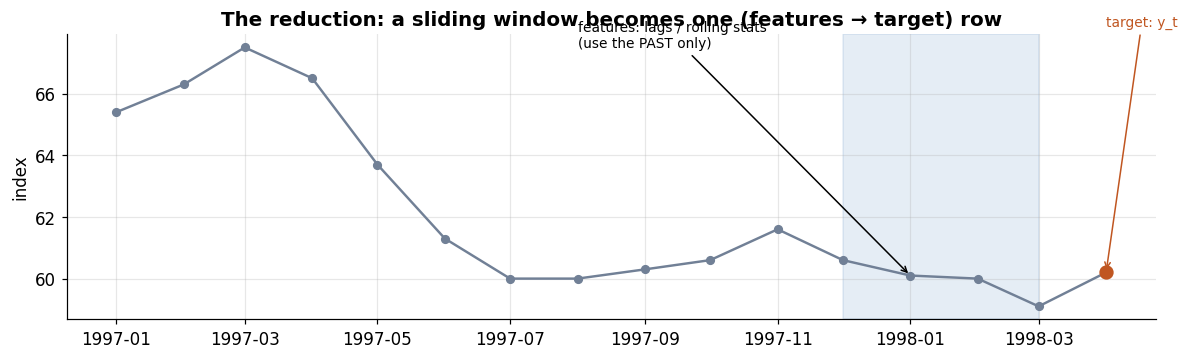

In [2]:
# a tiny schematic: one window -> one supervised row
fig, ax = plt.subplots(figsize=(11, 3.4))
seg = y.iloc[60:76]
ax.plot(seg.index, seg.values, "-o", color=PALETTE[5], ms=5)
origin = seg.index[-1]
ax.axvspan(seg.index[-5], seg.index[-2], color=PALETTE[0], alpha=0.12)
ax.annotate("features: lags / rolling stats\n(use the PAST only)",
            xy=(seg.index[-4], seg.iloc[-4]), xytext=(seg.index[-9], seg.max()),
            fontsize=9, arrowprops=dict(arrowstyle="->"))
ax.scatter([origin], [seg.iloc[-1]], color=PALETTE[1], zorder=5, s=70)
ax.annotate("target: y_t", xy=(origin, seg.iloc[-1]),
            xytext=(origin, seg.iloc[-1]+8), fontsize=9, color=PALETTE[1],
            arrowprops=dict(arrowstyle="->", color=PALETTE[1]))
ax.set_title("The reduction: a sliding window becomes one (features → target) row")
ax.set_ylabel("index"); plt.tight_layout(); plt.show()

## 2. Lag features — autoregression, generalized

The most fundamental features are **lags**: past values of the series,
$y_{t-1}, y_{t-2}, \dots, y_{t-p}$. A linear model on lag features *is* an AR
model (Part 4) — but now we can feed those same lags to a nonlinear learner that
captures interactions no ARIMA can. **Which lags?** The ACF/PACF from Part 2 guide
the short lags, and domain knowledge adds seasonal ones (lag 12 for monthly).

In [3]:
def make_lags(s, lags):
    out = pd.concat([s.shift(k) for k in lags], axis=1)
    out.columns = [f"lag{k}" for k in lags]
    return out

lags = make_lags(y, [1, 2, 3, 6, 12])
lags.head(14)

,lag1,lag2,lag3,lag6,lag12
date,,,,,
1992-01-01,NaN,NaN,NaN,NaN,NaN
1992-02-01,55.7,NaN,NaN,NaN,NaN
1992-03-01,55.5,55.7,NaN,NaN,NaN
1992-04-01,55.6,55.5,55.7,NaN,NaN
1992-05-01,54.1,55.6,55.5,NaN,NaN
1992-06-01,54.2,54.1,55.6,NaN,NaN
1992-07-01,54.8,54.2,54.1,55.7,NaN
1992-08-01,53.7,54.8,54.2,55.5,NaN
1992-09-01,53.8,53.7,54.8,55.6,NaN


The first rows are `NaN` — a lag-12 feature needs 12 months of history before it
exists. Those unusable rows are dropped once the full matrix is assembled. Each
column is a clean, causal predictor: at time *t* it contains only values from
*before* *t*.

## 3. Rolling & expanding aggregates, and differences

Beyond raw lags, **summaries of recent history** are powerful features: rolling
mean (local level), rolling std (local volatility), rolling min/max/median.
Expanding aggregates summarize *all* history to date. Differences and returns
capture momentum.

**The leakage guard (critical):** a plain `rolling(w).mean()` at time *t*
**includes** $y_t$ itself. To predict $y_t$ we must exclude it — so we `shift(1)`
**before** rolling, making every window end at $t-1$. This is the single most
common feature-engineering bug in forecasting.

In [4]:
def make_roll(s, windows):
    out = {}
    s_past = s.shift(1)                       # <-- guard: windows end at t-1
    for w in windows:
        out[f"rmean{w}"] = s_past.rolling(w).mean()
        out[f"rstd{w}"]  = s_past.rolling(w).std()
        out[f"rmin{w}"]  = s_past.rolling(w).min()
        out[f"rmax{w}"]  = s_past.rolling(w).max()
    out["mom_1"]  = s.shift(1) - s.shift(2)   # last month's change
    out["exp_mean"] = s.shift(1).expanding().mean()
    return pd.DataFrame(out)

roll = make_roll(y, [3, 6, 12])
roll[["rmean3", "rstd3", "rmean12", "mom_1", "exp_mean"]].dropna().head()

,rmean3,rstd3,rmean12,mom_1,exp_mean
date,,,,,
1993-01-01,51.933333,0.208167,53.875000,-0.1,53.875000
1993-02-01,52.533333,0.838650,53.691667,1.5,53.846154
1993-03-01,52.933333,0.814453,53.508333,-0.2,53.807143
1993-04-01,53.633333,0.416333,53.383333,0.8,53.826667
1993-05-01,53.733333,0.404145,53.358333,-0.3,53.825000


To *see* why the guard matters, compare a leaky centred/inclusive rolling mean
with the correct trailing one near a turning point — the leaky version hugs the
line because it already contains the current value.

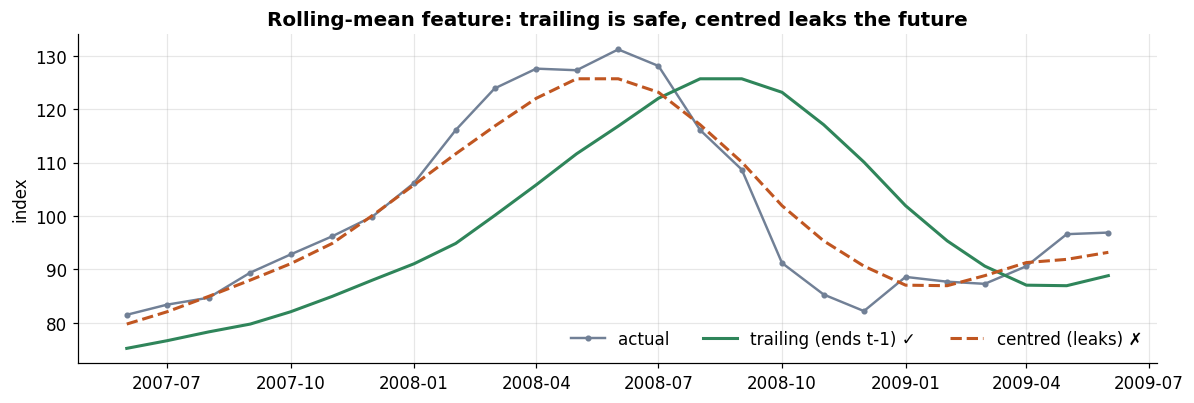

In [5]:
correct = y.shift(1).rolling(6).mean()
leaky   = y.rolling(6, center=True).mean()      # peeks at current + future
seg = slice("2007-06", "2009-06")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(y.loc[seg].index, y.loc[seg], color=PALETTE[5], marker="o", ms=3, label="actual")
ax.plot(correct.loc[seg].index, correct.loc[seg], color=PALETTE[2], lw=2, label="trailing (ends t-1) ✓")
ax.plot(leaky.loc[seg].index, leaky.loc[seg], color=PALETTE[1], lw=2, ls="--", label="centred (leaks) ✗")
ax.set_title("Rolling-mean feature: trailing is safe, centred leaks the future")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.show()

## 4. Calendar, cyclical, and Fourier features

Some features are **known in advance** — the calendar. Because we always know that
next month is, say, March, calendar features may legitimately use the *current*
timestamp (no leakage). Three encodings, in increasing sophistication:

- **Date-parts**: month, quarter, year as integers or one-hot.
- **Cyclical (sin/cos)**: encode month on a circle so December (12) sits next to
  January (1) — a plain integer would wrongly place them 11 apart.
- **Fourier terms**: pairs of sines/cosines at seasonal harmonics — a compact,
  smooth basis that captures seasonality with few features, and scales to long or
  multiple seasonal periods far better than one-hot months.

In [6]:
def calendar_features(idx, period=12, n_fourier=3):
    out = pd.DataFrame(index=idx)
    out["month"]   = idx.month
    out["quarter"] = idx.quarter
    t = idx.month  # position within the yearly cycle
    for k in range(1, n_fourier + 1):
        out[f"sin{k}"] = np.sin(2 * np.pi * k * t / period)
        out[f"cos{k}"] = np.cos(2 * np.pi * k * t / period)
    return out

cal = calendar_features(y.index, period=12, n_fourier=3)
cal.head(3)

,month,quarter,sin1,cos1,sin2,cos2,sin3,cos3
date,,,,,,,,
1992-01-01,1,1,0.500000,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17
1992-02-01,2,1,0.866025,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00
1992-03-01,3,1,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16


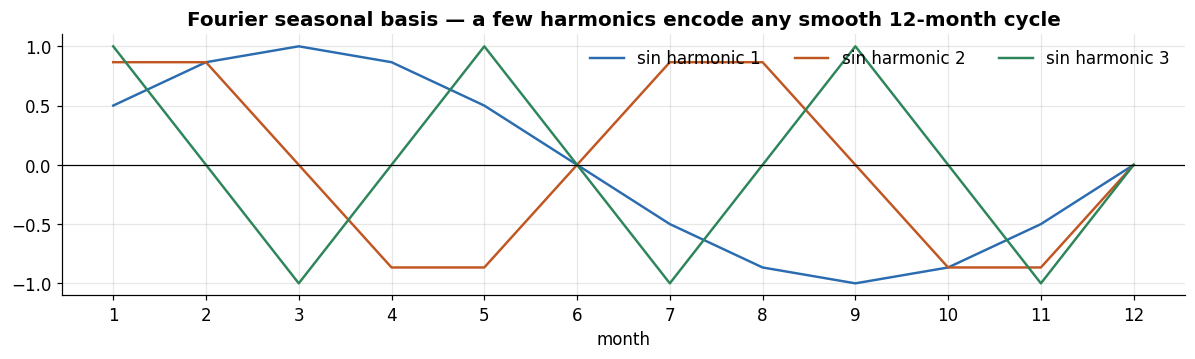

In [7]:
# how Fourier terms reconstruct a smooth seasonal shape
months = np.arange(1, 13)
fig, ax = plt.subplots(figsize=(11, 3.4))
for k, c in zip([1, 2, 3], PALETTE):
    ax.plot(months, np.sin(2*np.pi*k*months/12), color=c, label=f"sin harmonic {k}")
ax.set_xticks(months); ax.axhline(0, color="k", lw=.8)
ax.set_title("Fourier seasonal basis — a few harmonics encode any smooth 12-month cycle")
ax.set_xlabel("month"); ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.show()

> **Holidays.** For daily/weekly business data, **holiday** and **event** flags
> (Christmas, Black Friday, promotions) are among the strongest features —
> typically encoded as binary indicators, sometimes with lead/lag windows. Our
> monthly commodity data has no holiday structure, so we note the technique and
> move on; Prophet (Part 5) has a built-in holidays interface for when you need it.

## 5. Exogenous variables and target transformations

**Exogenous features.** Other series can help predict the target — but the Part 4/5
rule applies: to forecast $y_t$ you may use an exogenous variable's value only if
it is **known in advance**, otherwise use its **lag**. We add lagged Energy and VIX.

In [8]:
def exog_features(df, cols, lags):
    out = {}
    for c in cols:
        for k in lags:
            out[f"{c}_lag{k}"] = df[c].shift(k)
    return pd.DataFrame(out, index=df.index)

exo = exog_features(df, ["Energy_Price_Index", "VIX_Index"], [1, 3])
exo.dropna().head(3)

,Energy_Price_Index_lag1,Energy_Price_Index_lag3,VIX_Index_lag1,VIX_Index_lag3
date,,,,
1992-04-01,23.8,23.7,17.5,17.7
1992-05-01,25.2,23.8,16.6,17.5
1992-06-01,26.3,23.8,15.1,17.5


**Target transformations.** The *target* can be transformed to make the learning
problem easier — but every transform must be **invertible** so forecasts return to
the original scale, and any transform *fitted* from data (scaling) must be fit on
**training data only** (Part 6). Common choices: **log / Box–Cox** to stabilize
variance (Part 2), **differencing** the target to remove trend, and **scaling**.
The clean way to scale without leakage is inside a `Pipeline`, so the scaler
re-fits on each fold's training set.

In [9]:
# scaling belongs INSIDE the pipeline so it re-fits per fold (no leakage)
demo_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
print("Leakage-safe pipeline:", " -> ".join(s[0] for s in demo_pipe.steps))
print("The scaler's mean/std are learned on train folds only, never the test fold.")

Leakage-safe pipeline: standardscaler -> ridge
The scaler's mean/std are learned on train folds only, never the test fold.


## 6. A full feature pipeline and a backtested ML forecast

Now assemble everything into one matrix and let regressors forecast — scored with
the **walk-forward backtest** from Part 6. We build a one-step target and compare
**Ridge** and **Random Forest** against the **naive** benchmark.

In [10]:
def build_matrix(y, df):
    X = pd.concat([
        make_lags(y, [1, 2, 3, 6, 12]),
        make_roll(y, [3, 6, 12]),
        calendar_features(y.index, 12, n_fourier=2),
        exog_features(df, ["Energy_Price_Index", "VIX_Index"], [1, 3]),
    ], axis=1)
    # one-step target is y_t itself; features above already use only info <= t-1
    data = pd.concat([X, y.rename("y")], axis=1).dropna()
    return data.iloc[:, :-1], data["y"]

X, yt = build_matrix(y, df)
print("feature matrix:", X.shape, "\nfeatures:", list(X.columns))

feature matrix: (344, 29) 
features: ['lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'rmean3', 'rstd3', 'rmin3', 'rmax3', 'rmean6', 'rstd6', 'rmin6', 'rmax6', 'rmean12', 'rstd12', 'rmin12', 'rmax12', 'mom_1', 'exp_mean', 'month', 'quarter', 'sin1', 'cos1', 'sin2', 'cos2', 'Energy_Price_Index_lag1', 'Energy_Price_Index_lag3', 'VIX_Index_lag1', 'VIX_Index_lag3']


In [11]:
def backtest_ml(models, X, yt, n_splits=6, h=12, m=12):
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=h)
    acc = {name: [] for name in models}
    for tri, tei in tscv.split(X):
        Xtr, Xte = X.iloc[tri], X.iloc[tei]
        ytr, yte = yt.iloc[tri], yt.iloc[tei]
        denom = np.mean(np.abs(ytr.values[m:] - ytr.values[:-m]))
        for name, factory in models.items():
            if name == "Naive":
                pred = Xte["lag1"].values          # one-step naive = last value
            else:
                mdl = factory(); mdl.fit(Xtr, ytr); pred = mdl.predict(Xte)
            acc[name].append(mae(yte, pred) / denom)
    return pd.DataFrame({"model": list(acc), "MASE_mean": [round(np.mean(v), 3) for v in acc.values()],
                         "MASE_std": [round(np.std(v), 3) for v in acc.values()]}
                        ).sort_values("MASE_mean").reset_index(drop=True)

models = {
    "Naive": None,
    "Ridge": lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=300, random_state=0),
}
backtest_ml(models, X, yt)

,model,MASE_mean,MASE_std
0,Naive,0.214,0.089
1,Ridge,0.222,0.082
2,RandomForest,0.270,0.114


The honest result is instructive and consistent with the whole series: on a
single, smooth, monthly series the ML models **essentially tie the naive
benchmark** one step ahead — Ridge matches it, the forest does slightly worse
(more variance on little data). **The lag features simply recover the persistence
that naive already exploits.** The reduction did not fail — it worked exactly as
designed — but it reminds us that *capability is not the same as advantage*. The
ML payoff appears when there is structure to exploit: **many** series to learn
across, strong **exogenous** signals, and **nonlinear interactions** — precisely
what Part 8's global gradient-boosted models target.

What the model finds useful is itself informative — the **feature importances**.

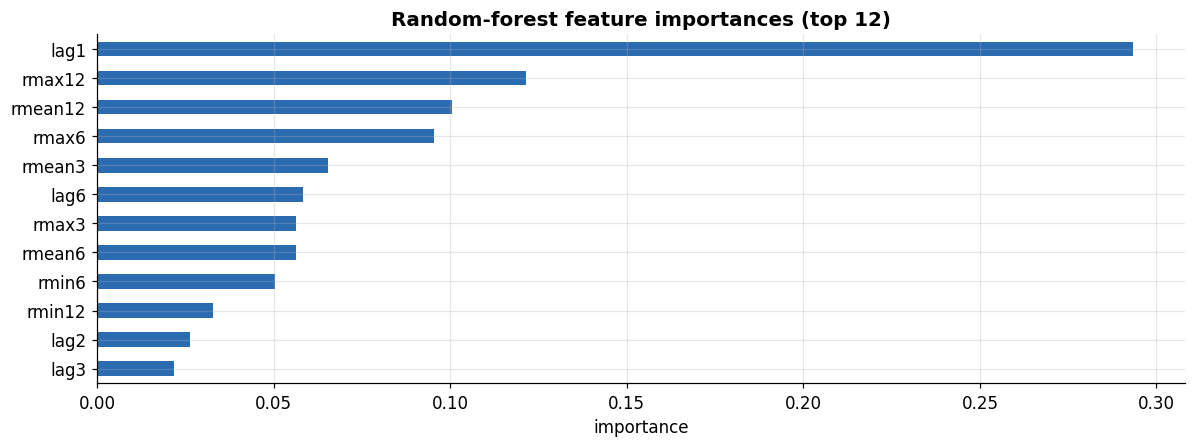

lag1       0.293
rmax12     0.121
rmean12    0.101
rmax6      0.095
rmean3     0.066
lag6       0.058
dtype: float64

In [12]:
rf = RandomForestRegressor(n_estimators=400, random_state=0).fit(X, yt)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 4.2))
imp.head(12).iloc[::-1].plot.barh(ax=ax, color=PALETTE[0])
ax.set_title("Random-forest feature importances (top 12)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()
imp.head(6).round(3)

Recent **lags** and **rolling means** dominate; the calendar/Fourier and
exogenous terms contribute little — a quantitative echo of everything Parts 1–5
found on this dataset (light seasonality, and energy that doesn't *lead* food, per
Part 5's Granger test). The features honestly report that the signal here is
mostly persistence.

### Multi-step with the direct strategy — and a leakage warning

To forecast 24 months with a one-step regressor we use the **direct** strategy
(Part 6): one model per horizon *h*, predicting $y_{t+h}$ from time-*t* features.

**Watch the target construction.** The direct target must be built from the
**training** series only — `y_train.shift(-h)`. If you instead shift the *full*
series and subset, the later training rows pull their targets from the *test*
period: instant leakage, and a forecast that looks unbelievably good. (This is the
Part 6 trap in a new disguise; it is genuinely easy to introduce here.)

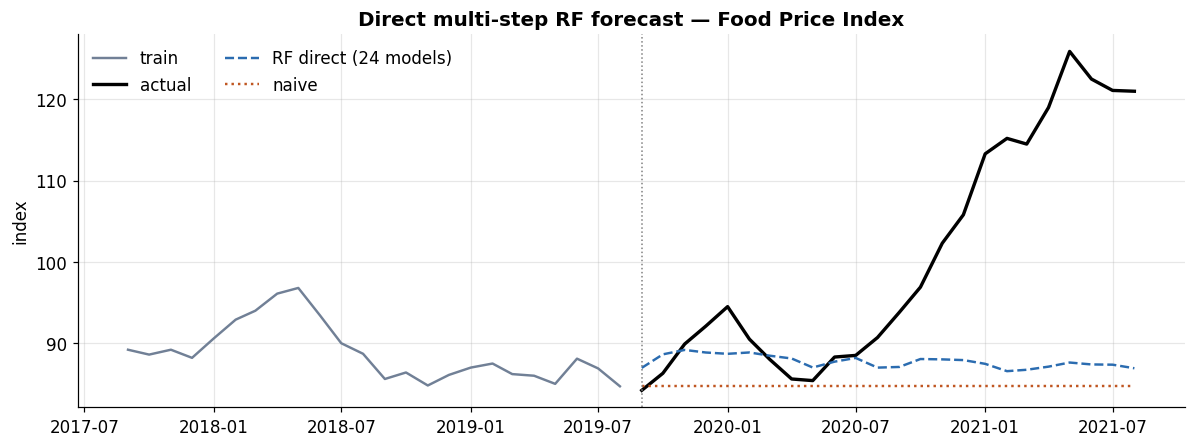

RF direct RMSE: 19.37   |   naive RMSE: 21.27


In [13]:
H = 24
ytr_full, yte = y.iloc[:-H], y.iloc[-H:]
Xall = pd.concat([
    make_lags(y, [1, 2, 3, 6, 12]),
    make_roll(y, [3, 6, 12]),
    calendar_features(y.index, 12, n_fourier=2),
    exog_features(df, ["Energy_Price_Index"], [1, 3]),
], axis=1)

direct = []
for h in range(1, H + 1):
    tgt = ytr_full.shift(-h)                       # <-- train-only target (leak-free)
    d = pd.concat([Xall.loc[ytr_full.index], tgt.rename("y")], axis=1).dropna()
    mdl = RandomForestRegressor(n_estimators=200, random_state=0).fit(d.iloc[:, :-1], d["y"])
    direct.append(mdl.predict(Xall.loc[[ytr_full.index[-1]]])[0])

naive_fc = np.repeat(ytr_full.iloc[-1], H)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(ytr_full.index[-24:], ytr_full.iloc[-24:], color=PALETTE[5], label="train")
ax.plot(yte.index, yte, color="black", lw=2.2, label="actual")
ax.plot(yte.index, direct, color=PALETTE[0], ls="--", label="RF direct (24 models)")
ax.plot(yte.index, naive_fc, color=PALETTE[1], ls=":", label="naive")
ax.axvline(yte.index[0], color="grey", lw=1, ls=":")
ax.set_title("Direct multi-step RF forecast — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
print(f"RF direct RMSE: {rmse(yte, direct):.2f}   |   naive RMSE: {rmse(yte, naive_fc):.2f}")

The forest forecast stays nearly flat and **under-shoots the 2020–21 surge** — a
tree cannot predict values above its training range, a fundamental limit of
tree-based extrapolation worth remembering. It still edges naive here, but no
feature set lets a bounded learner foresee an out-of-range shock. This is the
right expectation to carry into Part 8.

## 7. Automated feature extraction with `tsfresh`

Hand-crafting features is transparent but limited. **`tsfresh`** automatically
computes hundreds of features per window — statistical moments, autocorrelations,
entropy, spectral and nonlinearity measures — and can statistically **select** the
relevant ones. It expects **long format**: one row per (window id, time, value).

We build short rolling windows and extract the *minimal* feature set (fast) to
show the mechanics.

In [14]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

# long-format rolling windows of length 12, one id per window end
records, vals, idx = [], y.values, y.index
for t in range(12, len(y)):
    for j, v in enumerate(vals[t-12:t]):
        records.append({"id": idx[t], "time": j, "value": v})
long = pd.DataFrame(records)

feat = extract_features(long, column_id="id", column_sort="time", column_value="value",
                        default_fc_parameters=MinimalFCParameters(),
                        disable_progressbar=True, n_jobs=0)
print("tsfresh feature matrix:", feat.shape)
feat.iloc[:3, :6]

tsfresh feature matrix: (344, 10)


,value__sum_values,value__median,value__mean,value__length,value__standard_deviation,value__variance
1993-01-01,646.5,53.95,53.875000,12.0,1.345440,1.810208
1993-02-01,644.3,53.75,53.691667,12.0,1.229131,1.510764
1993-03-01,642.1,53.60,53.508333,12.0,1.103372,1.217431


Each window is now summarized by a battery of features, indexed by the window's
end date so it aligns with our target. With the full `EfficientFCParameters` you
get **hundreds** of features, and `tsfresh.select_features` runs hypothesis tests
to keep only those significantly related to the target.

Three cautions that Part 6 makes non-negotiable:

1. **Leakage** — build each window from **past** values only (as above), and run
   feature *selection* **inside** the CV fold, never on the full dataset.
2. **Overfitting** — hundreds of auto-features on a few hundred rows invites it;
   select aggressively and validate with the backtest.
3. **Cost & interpretability** — automated banks are compute-heavy and opaque;
   often a handful of hand-built lags/rolls (Sections 2–3) match them at a
   fraction of the cost. `tsfeatures` (from the Nixtla ecosystem) is a lighter
   alternative focused on classic time-series characteristics.

## 8. Exercises

1. **Lag depth.** Re-run the one-step backtest with only `[1]`, then `[1..12]`,
   then `[1..24]` lags. Where does adding lags stop helping?
2. **Fourier order.** Vary `n_fourier` from 1 to 6 in the calendar features for
   `Rice_Price`. Does more seasonal flexibility improve the backtest?
3. **Exogenous lift.** Add lagged fertilizer prices as exogenous features and
   check the RF importances. Do any exogenous features rise to the top?
4. **Transform the target.** Fit the pipeline to predict **log** Food Price Index,
   invert the forecast, and compare RMSE to the untransformed model.
5. **tsfresh selection.** Use `EfficientFCParameters` + `select_features` *inside*
   a single CV fold and compare a Ridge on the selected features to your
   hand-built matrix.

In [15]:
# --- Solution to Exercise 1 (setup) ---
for lag_set in ([1], [1,2,3,6,12], list(range(1,25))):
    Xe = pd.concat([make_lags(y, lag_set), y.rename("y")], axis=1).dropna()
    Xx, yy = Xe.iloc[:, :-1], Xe["y"]
    tscv = TimeSeriesSplit(n_splits=6, test_size=12); errs = []
    for tri, tei in tscv.split(Xx):
        den = np.mean(np.abs(yy.iloc[tri].values[12:] - yy.iloc[tri].values[:-12]))
        mdl = make_pipeline(StandardScaler(), Ridge(1.0)).fit(Xx.iloc[tri], yy.iloc[tri])
        errs.append(mae(yy.iloc[tei], mdl.predict(Xx.iloc[tei])) / den)
    print(f"lags={str(lag_set)[:20]:22s} -> MASE {np.mean(errs):.3f}")

lags=[1]                    -> MASE 0.221
lags=[1, 2, 3, 6, 12]       -> MASE 0.209
lags=[1, 2, 3, 4, 5, 6, 7   -> MASE 0.210


## 9. Key takeaways

- The **ML reduction** reframes forecasting as tabular regression: a sliding window
  becomes a row of **features → target**, so any regressor can forecast.
- **Lag features** are autoregression generalized; **rolling/expanding** aggregates
  and **differences** summarize recent history — always with the **`shift(1)`
  leakage guard** so windows end before the prediction time.
- **Calendar** features are known in advance (safe at time *t*); encode
  seasonality **cyclically** (sin/cos) or with compact **Fourier** terms; add
  **holidays** for business data.
- **Exogenous** drivers enter as **lags** (unless known in advance); **target
  transforms** must be invertible, and any fitted scaling belongs **inside a
  pipeline** to stay leak-free.
- **Automated extraction** (`tsfresh`) scales feature creation to hundreds of
  candidates — powerful, but demands in-fold selection, overfitting control, and a
  cost/interpretability check.
- On this single smooth series the ML models **recovered persistence** rather than
  beating it — capability, not yet advantage. The advantage arrives with scale and
  structure, which is exactly Part 8.

### What's next — Part 8: Machine Learning Forecasting
Part 8 puts real learners on this feature matrix: regularized linear models, and
**gradient-boosted trees** (XGBoost, LightGBM, CatBoost). Crucially it introduces
**global models** — one model trained across *many* series at once — and the
`skforecast`/`mlforecast` tooling that automates the recursive/direct machinery,
where the ML reduction finally pays off.